# Phase 5: ML Modeling
## Data Overview

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [46]:
df = pd.read_csv("cleaned_flight_data.csv")
df.shape

(544003, 23)

In [47]:
df.columns.tolist()

['FL_DATE',
 'Operating Carrier',
 'Aircraft Tail Number',
 'OP_CARRIER_FL_NUM',
 'ORIGIN_AIRPORT_ID',
 'ORIGIN',
 'ORIGIN_CITY_NAME',
 'ORIGIN_STATE_NM',
 'DEST_AIRPORT_ID',
 'DEST',
 'DEST_CITY_NAME',
 'DEST_STATE_NM',
 'Scheduled Departure Time',
 'DEP_DELAY',
 'Departure Delay ≥ 15 Minutes',
 'TAXI_OUT',
 'Scheduled Arrival Time',
 'ARR_DELAY',
 'Arrival Delay ≥ 15 Minutes',
 'Arrival Time Block',
 'CANCELLED',
 'ACTUAL_ELAPSED_TIME',
 'DISTANCE']

In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 544003 entries, 0 to 544002
Data columns (total 23 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   FL_DATE                       544003 non-null  object 
 1   Operating Carrier             544003 non-null  object 
 2   Aircraft Tail Number          544003 non-null  object 
 3   OP_CARRIER_FL_NUM             544003 non-null  int64  
 4   ORIGIN_AIRPORT_ID             544003 non-null  int64  
 5   ORIGIN                        544003 non-null  object 
 6   ORIGIN_CITY_NAME              544003 non-null  object 
 7   ORIGIN_STATE_NM               544003 non-null  object 
 8   DEST_AIRPORT_ID               544003 non-null  int64  
 9   DEST                          544003 non-null  object 
 10  DEST_CITY_NAME                544003 non-null  object 
 11  DEST_STATE_NM                 544003 non-null  object 
 12  Scheduled Departure Time      544003 non-nul

In [49]:
df.isnull().sum()


,0
FL_DATE,0
Operating Carrier,0
Aircraft Tail Number,0
OP_CARRIER_FL_NUM,0
ORIGIN_AIRPORT_ID,0
ORIGIN,0
ORIGIN_CITY_NAME,0
ORIGIN_STATE_NM,0
DEST_AIRPORT_ID,0
DEST,0


## Remove Cancelled Flights

In [50]:
df["CANCELLED"].value_counts()

,count
CANCELLED,
0,518368
1,25635


In [51]:
df = df[df["CANCELLED"] == 0].copy()
df.shape

(518368, 23)

## Feature Selection

In [52]:
df.drop(columns=[
    "ARR_DELAY",
    "ACTUAL_ELAPSED_TIME",
    "Arrival Time Block",
    "CANCELLED",
    "Aircraft Tail Number",
    "OP_CARRIER_FL_NUM",
    "ORIGIN_AIRPORT_ID",
    "DEST_AIRPORT_ID",
    "FL_DATE",
    "TAXI_OUT"
], inplace=True)

df.columns.tolist()

['Operating Carrier',
 'ORIGIN',
 'ORIGIN_CITY_NAME',
 'ORIGIN_STATE_NM',
 'DEST',
 'DEST_CITY_NAME',
 'DEST_STATE_NM',
 'Scheduled Departure Time',
 'DEP_DELAY',
 'Departure Delay ≥ 15 Minutes',
 'Scheduled Arrival Time',
 'Arrival Delay ≥ 15 Minutes',
 'DISTANCE']

In [53]:
df["Scheduled Departure Time"].head()

,Scheduled Departure Time
0,13:58
1,09:41
2,22:00
3,17:45
4,08:30


In [54]:
df["Departure Hour"] = df["Scheduled Departure Time"].str[:2].astype(int)
df["Departure Hour"].head()

,Departure Hour
0,13
1,9
2,22
3,17
4,8


In [55]:
df.drop(columns=["Scheduled Departure Time", "Scheduled Arrival Time"], inplace=True)
df.columns.tolist()

['Operating Carrier',
 'ORIGIN',
 'ORIGIN_CITY_NAME',
 'ORIGIN_STATE_NM',
 'DEST',
 'DEST_CITY_NAME',
 'DEST_STATE_NM',
 'DEP_DELAY',
 'Departure Delay ≥ 15 Minutes',
 'Arrival Delay ≥ 15 Minutes',
 'DISTANCE',
 'Departure Hour']

## EDA


In [56]:
num_col = ["DEP_DELAY", "DISTANCE"]
df[num_col].describe()

,DEP_DELAY,DISTANCE
count,518368.000000,518368.000000
mean,13.039408,848.698486
std,60.809936,605.831339
min,-59.000000,31.000000
25%,-7.000000,404.000000
50%,-2.000000,708.000000
75%,9.000000,1085.000000
max,3339.000000,4983.000000


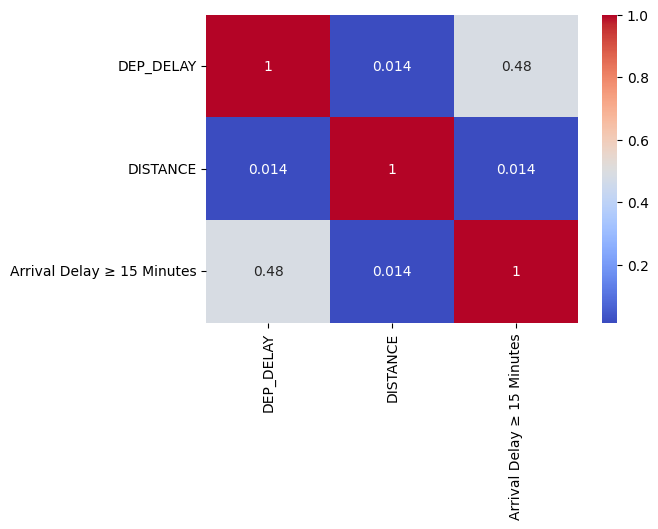

In [57]:
plt.figure(figsize=(6,4))
sns.heatmap(df[num_col + ["Arrival Delay ≥ 15 Minutes"]].corr(), annot=True, cmap="coolwarm")
plt.show()

### Correlation with Target

In [58]:
df.corr(numeric_only=True)["Arrival Delay ≥ 15 Minutes"].sort_values(ascending=False)

,Arrival Delay ≥ 15 Minutes
Arrival Delay ≥ 15 Minutes,1.000000
Departure Delay ≥ 15 Minutes,0.719650
DEP_DELAY,0.484977
Departure Hour,0.098506
DISTANCE,0.013877


### Analytical Question 1: Delay Rate by Carrier

In [59]:
delay_rate = (df.groupby("Operating Carrier")["Arrival Delay ≥ 15 Minutes"]
              .mean() * 100).round(2).sort_values(ascending=False)

delay_rate

,Arrival Delay ≥ 15 Minutes
Operating Carrier,
JetBlue Airways,31.58
Spirit Airlines,28.10
Frontier Airlines,27.94
PSA Airlines,24.22
Allegiant Air,23.97
American Airlines,23.91
SkyWest Airlines,23.00
Alaska Airlines,20.96
Republic Airways,20.40


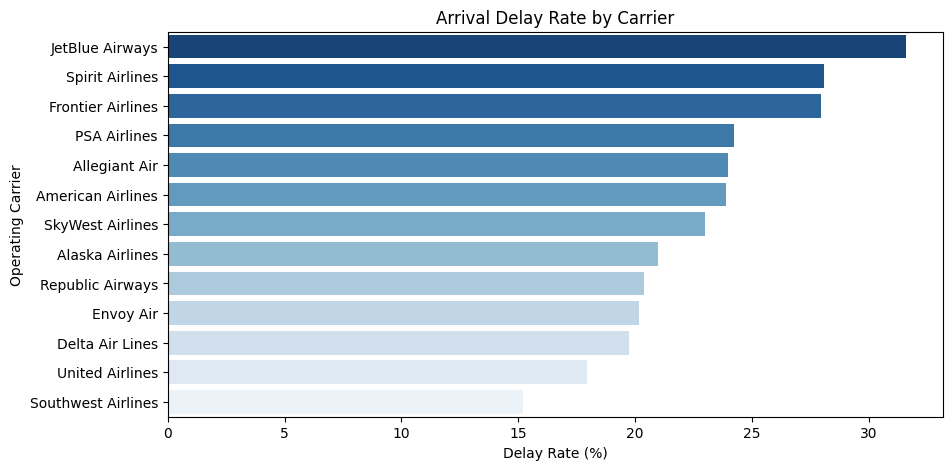

In [60]:
plt.figure(figsize=(10,5))
sns.barplot(x=delay_rate.values, y=delay_rate.index, hue=delay_rate.index, palette="Blues_r", legend=False)
plt.xlabel("Delay Rate (%)")
plt.ylabel("Operating Carrier")
plt.title("Arrival Delay Rate by Carrier")
plt.show()

### Analytical Question 3: Delay Rate by Origin Airport

In [61]:
top_origin_delay = (df.groupby("ORIGIN")["Arrival Delay ≥ 15 Minutes"]
                     .agg(["mean", "count"]))
top_origin_delay = top_origin_delay[top_origin_delay["count"] >= 500]
top_origin_delay["mean"] = (top_origin_delay["mean"] * 100).round(2)
top_origin_delay = top_origin_delay.sort_values("mean", ascending=False)

top_origin_delay.head(15)

,mean,count
ORIGIN,,
SBN,41.04,614
GRR,36.82,1347
DTW,35.14,9145
SYR,32.76,693
ORD,32.52,24192
ATW,31.04,596
ROC,30.44,703
HPN,29.79,846
FAR,29.08,557


### Delay Rate by Departure Hour

In [62]:
hourly_delay = (df.groupby("Departure Hour")["Arrival Delay ≥ 15 Minutes"]
                 .mean() * 100).round(2)

hourly_delay

,Arrival Delay ≥ 15 Minutes
Departure Hour,
0,13.46
1,20.68
2,28.24
3,27.78
4,50.00
5,10.99
6,12.83
7,15.05
8,16.78


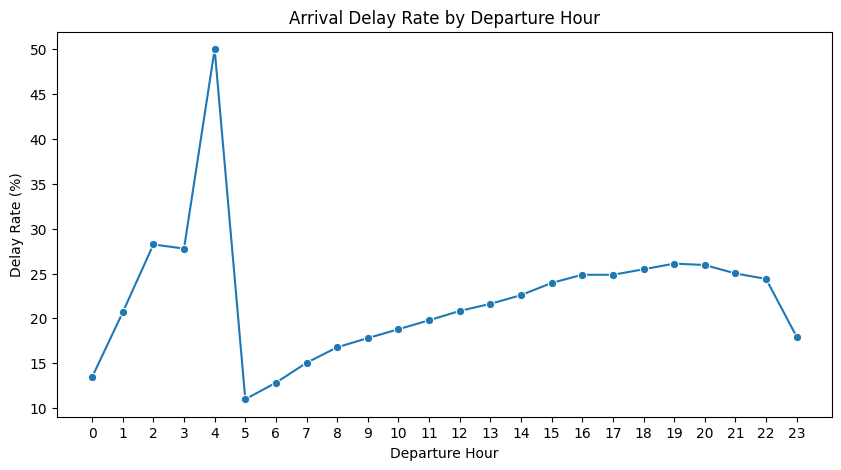

In [63]:
plt.figure(figsize=(10,5))
sns.lineplot(x=hourly_delay.index, y=hourly_delay.values, marker="o")
plt.xlabel("Departure Hour")
plt.ylabel("Delay Rate (%)")
plt.title("Arrival Delay Rate by Departure Hour")
plt.xticks(range(0,24))
plt.show()

## Encoding

In [64]:
df.drop(columns=[
    "ORIGIN_CITY_NAME", "ORIGIN_STATE_NM",
    "DEST_CITY_NAME", "DEST_STATE_NM"
], inplace=True)

df.columns.tolist()

['Operating Carrier',
 'ORIGIN',
 'DEST',
 'DEP_DELAY',
 'Departure Delay ≥ 15 Minutes',
 'Arrival Delay ≥ 15 Minutes',
 'DISTANCE',
 'Departure Hour']

In [65]:
top_n = 20

top_origins = df["ORIGIN"].value_counts().nlargest(top_n).index
df["ORIGIN"] = df["ORIGIN"].apply(lambda x: x if x in top_origins else "Other")

top_dests = df["DEST"].value_counts().nlargest(top_n).index
df["DEST"] = df["DEST"].apply(lambda x: x if x in top_dests else "Other")

df["ORIGIN"].value_counts()

,count
ORIGIN,
Other,246528
ORD,24192
DEN,24070
ATL,23365
DFW,21842
PHX,16176
LAX,14493
LAS,13440
MCO,13252


In [66]:
df["Operating Carrier"].unique()

array(['American Airlines', 'Alaska Airlines', 'JetBlue Airways',
       'Delta Air Lines', 'Frontier Airlines', 'Allegiant Air',
       'Envoy Air', 'Spirit Airlines', 'PSA Airlines', 'SkyWest Airlines',
       'United Airlines', 'Southwest Airlines', 'Republic Airways'],
      dtype=object)

In [67]:
df = pd.get_dummies(df, columns=["Operating Carrier", "ORIGIN", "DEST"], drop_first=True, dtype=int)
df.head()

,DEP_DELAY,Departure Delay ≥ 15 Minutes,Arrival Delay ≥ 15 Minutes,DISTANCE,Departure Hour,Operating Carrier_Allegiant Air,Operating Carrier_American Airlines,Operating Carrier_Delta Air Lines,Operating Carrier_Envoy Air,Operating Carrier_Frontier Airlines,...,DEST_LAX,DEST_LGA,DEST_MCO,DEST_MIA,DEST_ORD,DEST_Other,DEST_PHX,DEST_SEA,DEST_SFO,DEST_SLC
0,85,1,1,2611,13,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,71,1,1,2475,9,0,1,0,0,0,...,1,0,0,0,0,0,0,0,0,0
2,27,1,1,2611,22,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,1,2475,17,0,1,0,0,0,...,1,0,0,0,0,0,0,0,0,0
4,0,0,0,2475,8,0,1,0,0,0,...,0,0,0,0,0,1,0,0,0,0


## Splitting

In [68]:
X = df.drop("Arrival Delay ≥ 15 Minutes", axis=1)
y = df["Arrival Delay ≥ 15 Minutes"]

In [69]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [70]:
X_train.shape, X_test.shape

((414694, 56), (103674, 56))

In [71]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()

X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)

## Build Model ==> Logistic Regression

In [72]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=2000, random_state=42).fit(X_train_scaled, y_train)

In [73]:
y_pred = lr.predict(X_test_scaled)
y_pred[:10]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 1])

In [74]:
y_pred_prob = lr.predict_proba(X_test_scaled)[:, 1]
y_pred_prob[:10]

array([0.02539224, 0.0402622 , 0.03837835, 0.06087719, 0.04024815,
       0.06890934, 0.02867654, 0.11984717, 0.03320762, 0.61197836])

# Phase 6: Evaluation
## Evaluation Metrics

In [80]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

acc = accuracy_score(y_test, y_pred)
pre = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy: ", acc, "Precision: ", pre, "Recall: ", rec, "F1-Score: ", f1)

Accuracy:  0.9219090610953566 Precision:  0.8903000291290416 Recall:  0.7109560362875087 F1-Score:  0.7905845835488877


In [81]:
print(classification_report(y_test, y_pred, target_names=["No Delay", "Delayed"]))

              precision    recall  f1-score   support

    No Delay       0.93      0.98      0.95     82179
     Delayed       0.89      0.71      0.79     21495

    accuracy                           0.92    103674
   macro avg       0.91      0.84      0.87    103674
weighted avg       0.92      0.92      0.92    103674



## Confusion Matrix

In [82]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[80296,  1883],
       [ 6213, 15282]])

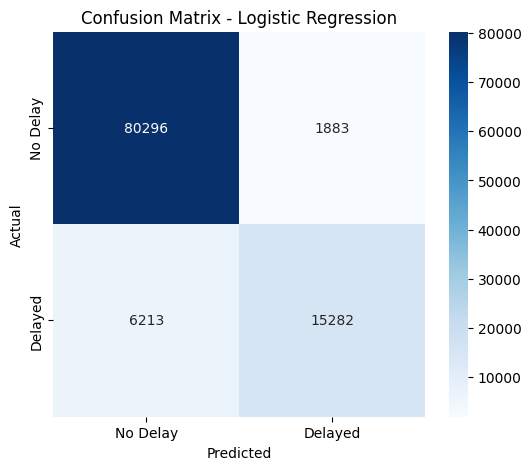

In [83]:
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Delay", "Delayed"],
            yticklabels=["No Delay", "Delayed"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

## Feature Importance

In [84]:
imp = pd.DataFrame({"Feature": X.columns, "Coefficient": lr.coef_[0]})
imp["Importance"] = imp["Coefficient"].abs()

FI = imp.sort_values(by="Importance", ascending=False)
FI.head(10)

,Feature,Coefficient,Importance
0,DEP_DELAY,6.458226,6.458226
50,DEST_ORD,0.232845,0.232845
51,DEST_Other,0.187549,0.187549
13,Operating Carrier_Southwest Airlines,-0.177147,0.177147
38,DEST_DCA,0.143028,0.143028
1,Departure Delay ≥ 15 Minutes,0.130586,0.130586
43,DEST_FLL,0.102527,0.102527
21,ORIGIN_DTW,0.095200,0.095200
48,DEST_MCO,0.093446,0.093446
39,DEST_DEN,0.087718,0.087718


## Build Model ==> Decision Tree

In [85]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(max_depth=8, random_state=42).fit(X_train_scaled, y_train)

In [86]:
y_pred_dt = dt.predict(X_test_scaled)

In [87]:
acc_dt = accuracy_score(y_test, y_pred_dt)
pre_dt = precision_score(y_test, y_pred_dt)
rec_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)

print("Accuracy: ", acc_dt, "Precision: ", pre_dt, "Recall: ", rec_dt, "F1-Score: ", f1_dt)

Accuracy:  0.9222080753130004 Precision:  0.9056911551474142 Recall:  0.6974180041870203 F1-Score:  0.7880253370830814


## Model Comparison

In [88]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree"],
    "Accuracy": [acc, acc_dt],
    "Precision": [pre, pre_dt],
    "Recall": [rec, rec_dt],
    "F1-Score": [f1, f1_dt]
})

comparison

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.921909,0.890300,0.710956,0.790585
1,Decision Tree,0.922208,0.905691,0.697418,0.788025


## Save Model Artifacts

In [89]:
import joblib

joblib.dump(lr, "logistic_model.pkl")
joblib.dump(sc, "scaler.pkl")
joblib.dump(X.columns.tolist(), "model_columns.pkl")

['model_columns.pkl']

In [92]:
from google.colab import files

files.download("logistic_model.pkl")
files.download("scaler.pkl")
files.download("model_columns.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>